In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('C:/Users/pc/OneDrive/Documentos/Fake_Job_Detection_Project/data/fake_job_postings.csv')
print(df.shape)
print(df.head())
print(df['fraudulent'].value_counts())

(17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                         descripti

In [3]:
df['text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
)

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)
print("Text cleaning done!")
print(df['text'].head(3))




Text cleaning done!
0    marketing intern were food and weve created a ...
1    customer service cloud video production second...
2    commissioning machinery assistant cma valor se...
Name: text, dtype: object


In [4]:
X = df['text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Testing set size:", X_test_tfidf.shape)

Training set size: (14304, 5000)
Testing set size: (3576, 5000)


In [5]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds):.4f}")

=== Logistic Regression Results ===
Accuracy:  0.9726
Precision: 1.0000
Recall:    0.4335
F1 Score:  0.6048


In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_preds = rf_model.predict(X_test_tfidf)

print("=== Random Forest Results ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Precision: {precision_score(y_test, rf_preds):.4f}")
print(f"Recall:    {recall_score(y_test, rf_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_preds):.4f}")

=== Random Forest Results ===
Accuracy:  0.9799
Precision: 0.9903
Recall:    0.5896
F1 Score:  0.7391


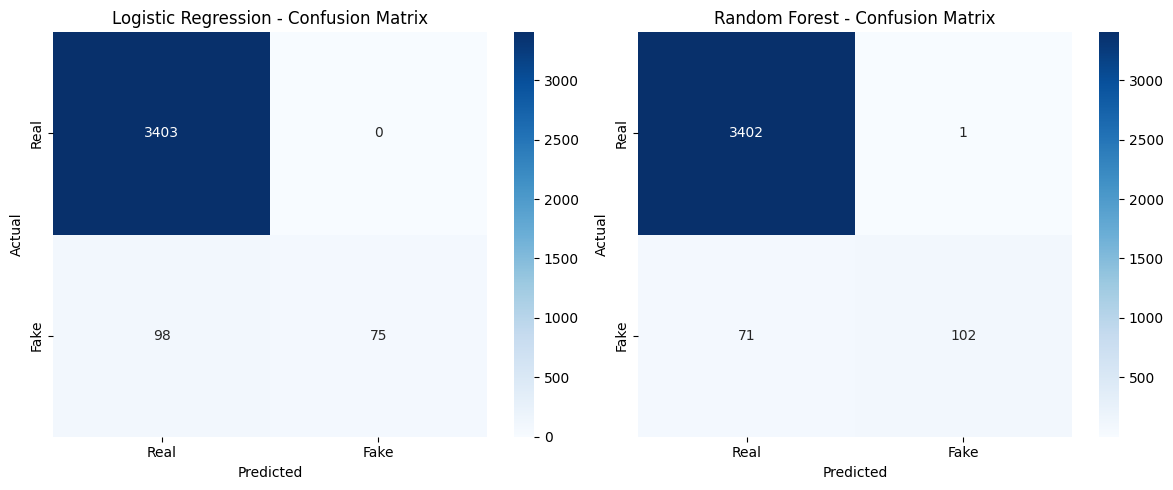

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes, [lr_preds, rf_preds], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(f'{title} - Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
import os

os.makedirs('models', exist_ok=True)

plt.tight_layout()
plt.savefig('models/confusion_matrices.png', dpi=150)
plt.show()


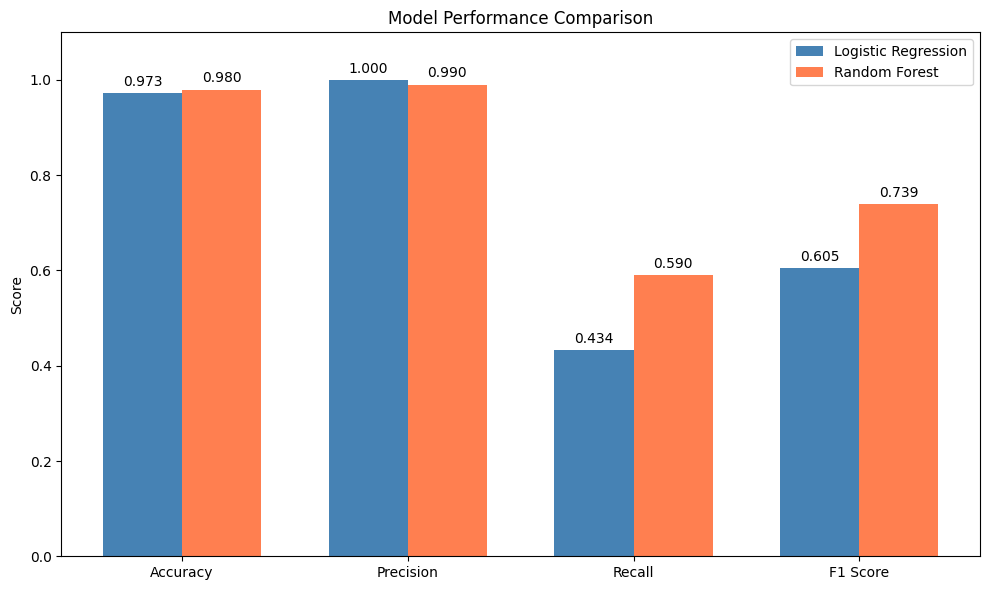

In [8]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [accuracy_score(y_test, lr_preds), precision_score(y_test, lr_preds),
             recall_score(y_test, lr_preds), f1_score(y_test, lr_preds)]
rf_scores = [accuracy_score(y_test, rf_preds), precision_score(y_test, rf_preds),
             recall_score(y_test, rf_preds), f1_score(y_test, rf_preds)]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('models/model_comparison.png', dpi=150)
plt.show()

In [9]:
joblib.dump(lr_model, 'models/logistic_regression_model.pkl')
joblib.dump(rf_model, 'models/random_forest_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print("✅ All models saved successfully!")

✅ All models saved successfully!
